# PT → Image converter
Loads a `.pt` ECG tensor `(n_leads, n_samples)` and renders each lead as a stacked waveform plot.

In [2]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 3.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 4.4 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 5.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 5.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.5 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.7 MB/s  0:00:00

   -------- ------------------------------- 1/5 [fonttools]
   -------- ------------------------------- 1/5 [fontt

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
PT_FILE   = "PTIMG/02860_lr-stach.pt"   # ← change to your ECG .pt file
OUT_FILE  = None          # e.g. "ecg_output.png"; None → only display, don't save
SAMPLE_HZ = 100           # PTB-XL is 100 Hz
SCALE_MV  = True          # divide raw values by 1000 to convert µV → mV

LEAD_LABELS = ["I", "II", "III", "aVR", "aVL", "aVF",
               "V1", "V2", "V3", "V4", "V5", "V6"]

# ── LOAD ──────────────────────────────────────────────────────────────────────
raw = torch.load(PT_FILE, map_location="cpu", weights_only=True)

if not isinstance(raw, torch.Tensor):
    raise TypeError(f"Expected a torch.Tensor in the .pt file, got {type(raw)}")

data = raw.float().numpy()   # → numpy, shape (n_leads, n_samples) or (n_samples,)

# Normalise shape to 2-D (n_leads, n_samples)
if data.ndim == 1:
    data = data[np.newaxis, :]   # treat as single lead
elif data.ndim != 2:
    raise ValueError(f"Unexpected tensor shape {data.shape}; expected 1-D or 2-D.")

n_leads, n_samples = data.shape

if SCALE_MV and np.abs(data).max() > 10:
    data = data / 1000.0   # µV → mV

# Use standard 12-lead names when possible, else generic labels
if n_leads <= len(LEAD_LABELS):
    labels = LEAD_LABELS[:n_leads]
else:
    labels = [f"Lead {i+1}" for i in range(n_leads)]

time_s = np.arange(n_samples) / SAMPLE_HZ   # seconds

print(f"Loaded '{PT_FILE}' — {n_leads} lead(s) × {n_samples} samples "
      f"({n_samples / SAMPLE_HZ:.1f} s @ {SAMPLE_HZ} Hz)")
print(f"Signal range: [{data.min():.3f}, {data.max():.3f}] mV")

Loaded 'PTIMG/02860_lr-stach.pt' — 12 lead(s) × 1000 samples (10.0 s @ 100 Hz)
Signal range: [-5.474, 5.703] mV


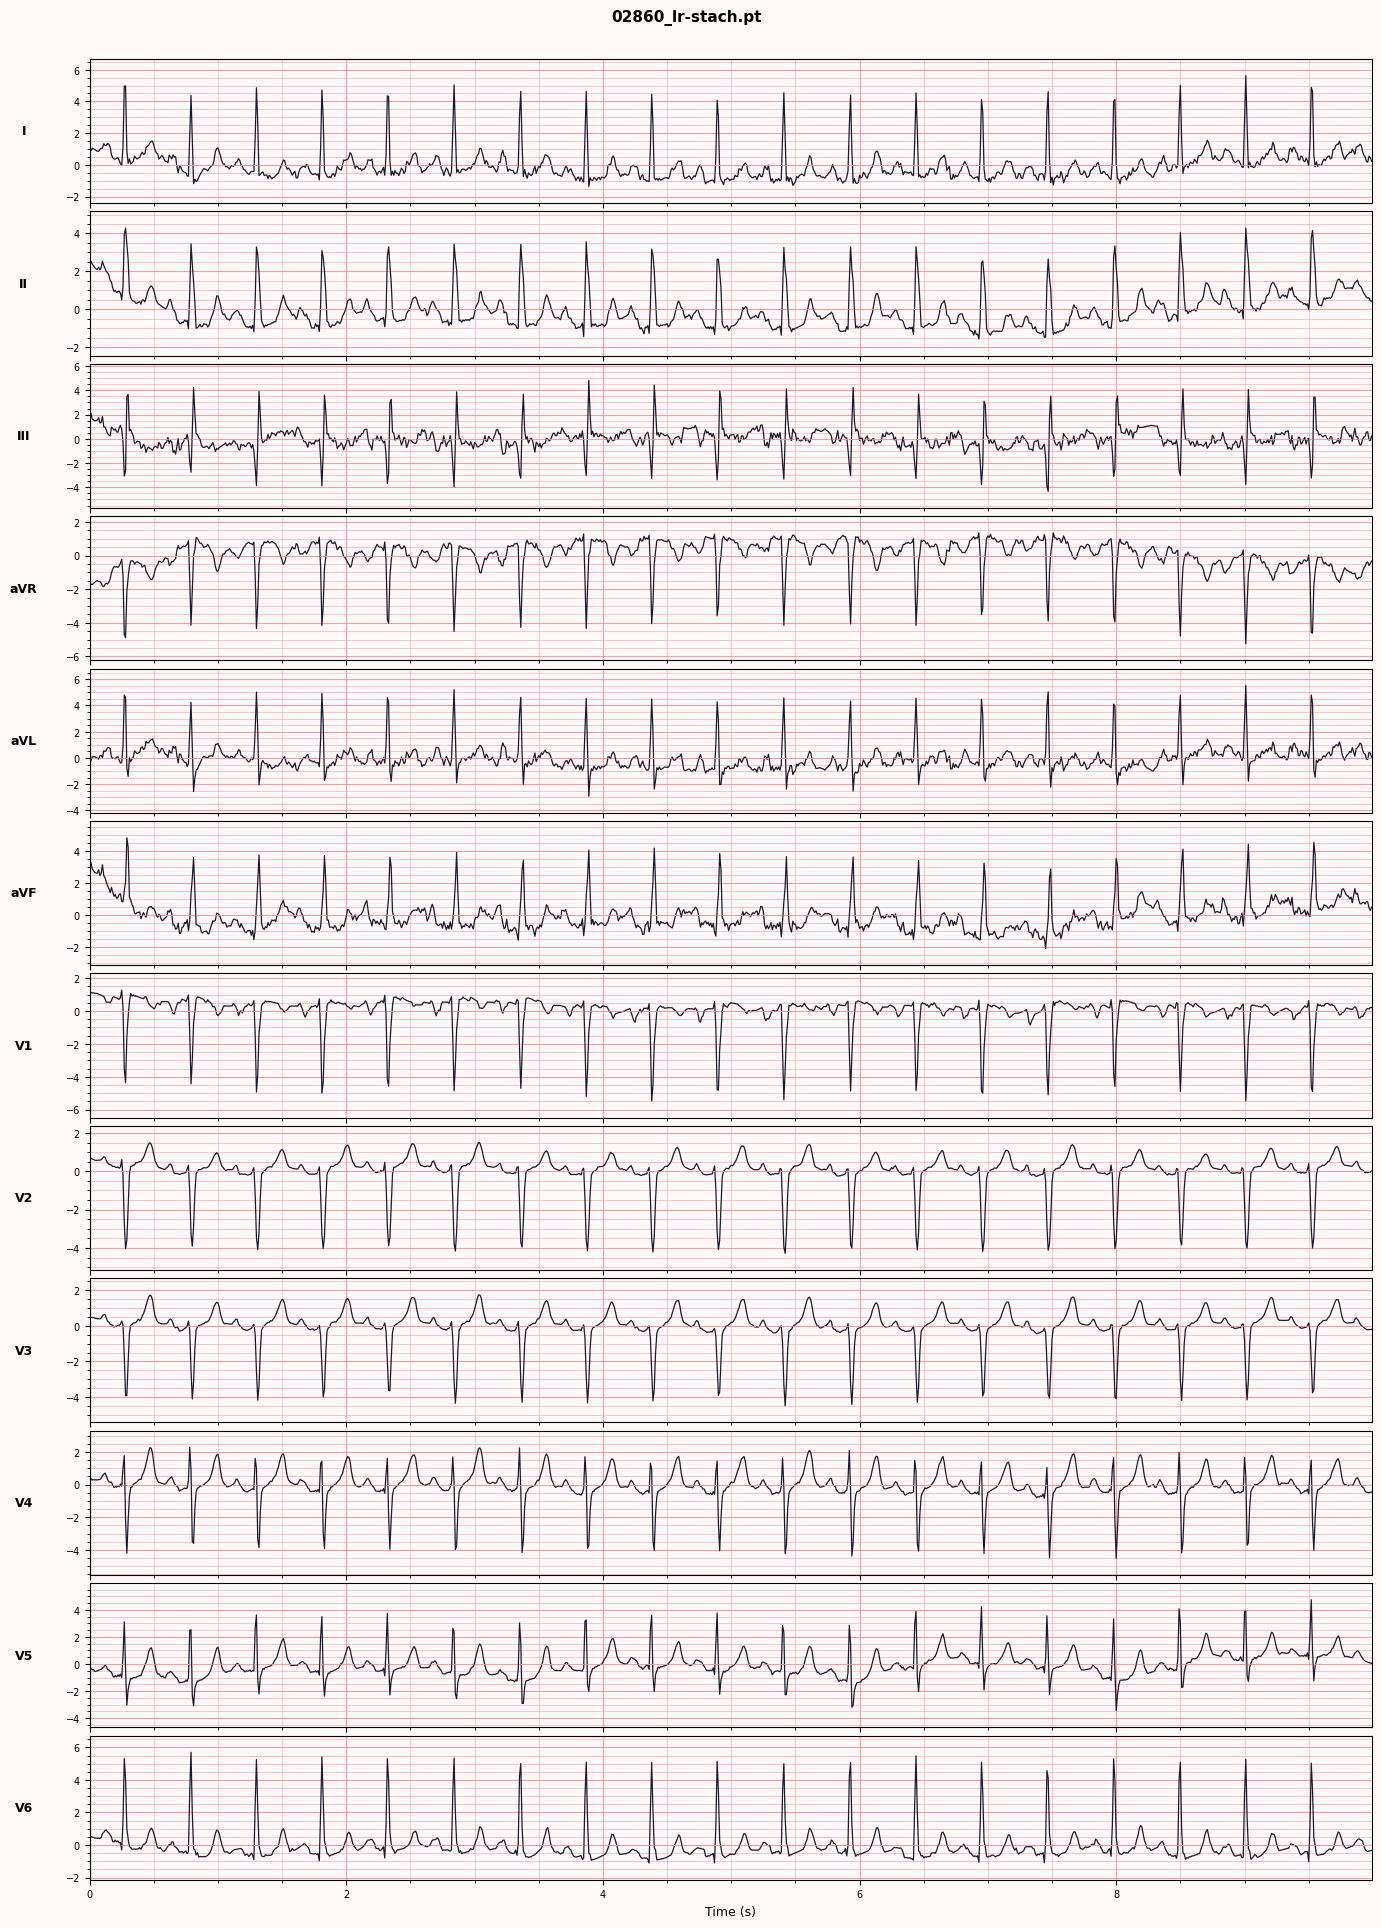

In [9]:
# ── PLOT ──────────────────────────────────────────────────────────────────────
ROW_HEIGHT = 1.6          # inches per lead row
FIG_WIDTH  = 14           # total figure width in inches
LINE_COLOR = "#1a1a2e"    # dark navy waveform
GRID_COLOR = "#f4a0a0"    # classic ECG pink grid
BG_COLOR   = "#fff8f8"    # faint warm background

fig, axes = plt.subplots(
    n_leads, 1,
    figsize=(FIG_WIDTH, ROW_HEIGHT * n_leads),
    sharex=True
)

# Make axes always iterable (single-lead edge case)
if n_leads == 1:
    axes = [axes]

fig.patch.set_facecolor(BG_COLOR)

for ax, lead_data, label in zip(axes, data, labels):
    ax.set_facecolor(BG_COLOR)

    # ECG-paper-style grid
    ax.grid(True, which="minor", color=GRID_COLOR, linewidth=0.4)
    ax.grid(True, which="major", color=GRID_COLOR, linewidth=0.8)
    ax.minorticks_on()

    ax.plot(time_s, lead_data, color=LINE_COLOR, linewidth=0.9, antialiased=True)
    ax.axhline(0, color=GRID_COLOR, linewidth=0.6, linestyle="--")

    ax.set_ylabel(label, fontsize=9, fontweight="bold", rotation=0,
                  labelpad=30, va="center")
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

    # y-limits with a small margin around the signal
    sig_min, sig_max = lead_data.min(), lead_data.max()
    margin = max((sig_max - sig_min) * 0.15, 0.05)
    ax.set_ylim(sig_min - margin, sig_max + margin)

axes[-1].set_xlabel("Time (s)", fontsize=9)
axes[-1].set_xlim(time_s[0], time_s[-1])

fig.suptitle(Path(PT_FILE).name, fontsize=11, fontweight="bold", y=1.002)
fig.tight_layout(h_pad=0.2)

if OUT_FILE:
    fig.savefig(OUT_FILE, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
    print(f"Saved → {OUT_FILE}")

plt.show()